## 1. Class balance

In [45]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import imagehash

random.seed(42)

data_root = Path("../data/raw")

rows = []

for split in ["train", "test"]:
    for cls in ["def_front", "ok_front"]:
        path = data_root / split / cls
        count = len(list(path.glob("*")))
        print(f"{split}/{cls}: {count}")

        for im in path.glob("*"):
            img = Image.open(im)
            gray = img.convert("L")
            arr = np.asarray(gray, dtype=np.float64)
            row = {
                "filepath": str(im),
                "split": split,
                "class": cls,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "mean_px": arr.mean(),
                "std_px": arr.std(),
                "phash": imagehash.phash(img),
            }
            rows.append(row)


train/def_front: 3758
train/ok_front: 2875
test/def_front: 453
test/ok_front: 262


In [46]:
img_df = pd.DataFrame(rows)
print(img_df.shape)
img_df.head()

(7348, 9)


,filepath,split,class,width,height,mode,mean_px,std_px,phash
0,../data/raw/train/def_front/cast_def_0_9253.jpeg,train,def_front,300,300,RGB,152.461133,62.767939,f09287691c67339e
1,../data/raw/train/def_front/cast_def_0_9071.jpeg,train,def_front,300,300,RGB,141.844200,54.154159,af87929869392667
2,../data/raw/train/def_front/cast_def_0_838.jpeg,train,def_front,300,300,RGB,138.020244,57.387111,e56b9a3639982633
3,../data/raw/train/def_front/cast_def_0_6849.jpeg,train,def_front,300,300,RGB,154.651689,63.690401,bda4d2da6c192636
4,../data/raw/train/def_front/cast_def_0_5259.jpeg,train,def_front,300,300,RGB,138.613878,60.255102,fa68871f3cd83261


### Findings
- Train: def_front=3758, ok_front=2875 (~57/43 split)
- Test: def_front=453, ok_front=262 (~63/37 split)
- Moderate imbalance, not severe. Decisions:
  - Use per-class precision/recall/F1 (or balanced accuracy) as the primary metric, not raw accuracy — a majority-class classifier already scores ~57-63%.
  - Consider class-weighted loss in training (Stage 3).
- Train/test imbalance ratios differ slightly — test isn't a perfectly stratified subset of train. Worth keeping in mind, not a blocker.

## 2. Image dimensions & pixel statistics

In [84]:
# Are all images the same size/mode?
img_df[["width", "height", "mode"]].drop_duplicates()

,width,height,mode
0,300,300,RGB


In [85]:
# Do the two classes differ in pixel intensity?
img_df.groupby(["split", "class"])[["mean_px", "std_px"]].describe()

mean_px                                                \
                  count        mean       std         min         25%   
split class                                                             
test  def_front   453.0  138.852397  5.558122  125.602856  135.150811   
      ok_front    262.0  148.879140  6.562513  132.233922  141.861236   
train def_front  3758.0  139.304465  5.837121  124.286322  135.160856   
      ok_front   2875.0  149.856345  6.466955  123.840700  143.115328   

                                                     std_px             \
                        50%         75%         max   count       mean   
split class                                                              
test  def_front  138.408378  141.991800  156.275967   453.0  58.281204   
      ok_front   151.292094  153.698928  158.659189   262.0  61.981048   
train def_front  138.893056  142.527017  157.016611  3758.0  58.610393   
      ok_front   151.939800  154.107189  160.617278  2875.0  62.294531   

                                                                       \
                      std        min        25%        50%        75%   
split class                                                             
test  def_front  3.091318  51.575420  55.799530  58.647348  60.414216   
      ok_front   2.608294  51.032802  59.971415  61.785862  63.839031   
train def_front  3.082920  51.545823  56.170844  59.030064  60.609400   
      ok_front   2.743604  49.638779  60.522986  62.073374  64.499918   

                            
                       max  
split class                 
test  def_front  68.419227  
      ok_front   66.842494  
train def_front  68.422486  
      ok_front   67.583266

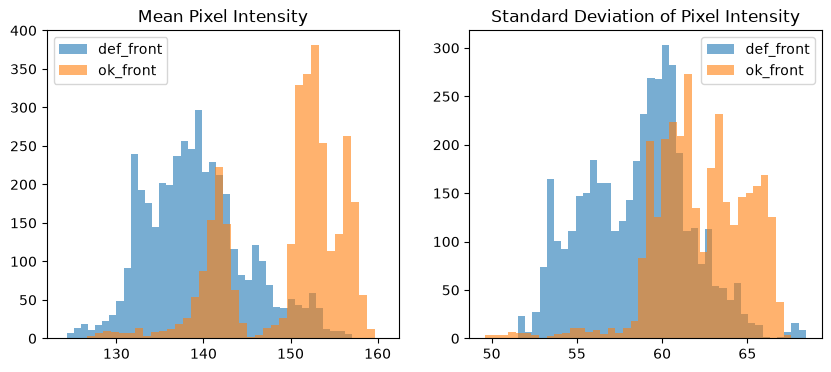

In [86]:
# Visualize the distribution of pixel intensity for each class
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for cls in ["def_front", "ok_front"]:
    subset = img_df[img_df["class"] == cls]
    axes[0].hist(subset["mean_px"], bins=40, alpha=0.6, label=cls)
    axes[1].hist(subset["std_px"], bins=40, alpha=0.6, label=cls)
axes[0].set_title("Mean Pixel Intensity")
axes[1].set_title("Standard Deviation of Pixel Intensity")
axes[0].legend()
axes[1].legend()
fig.savefig("../reports/figures/pixel_intensity_distribution.png", bbox_inches="tight")

### Findings
- All images uniform: 300×300, RGB. No corrupt/off-size files.
- Train/test are consistent per class (e.g. def_front mean_px ≈139.3 train vs ≈138.9 test; ok_front ≈149.9 vs ≈148.9) — no distribution shift between the two splits on this measure.
- def_front skews darker (def_front mean ≈139, ok_front mean ≈150), moderate overlap, physically sensible given that defects appear as dark regions.
- Contrast (std_px) heavily overlaps between classes, since defects in this dataset are subtle localized marks, not the type of thing that dramatically changes the overall contrast.
- Neither mean_px nor std_px cleanly separates the classes on its own (overlap zones in both histograms) — a simple brightness/contrast threshold wouldn't reliably classify these images. Supports the choice of a CNN in Stage 3, which can learn the spatial location of a defect rather than relying on whole-image statistics.

## 3. Sample Image grids

In [50]:
images_by_class = {}
for cls in ["def_front", "ok_front"]:
    path = data_root / "train" / cls
    images_by_class[cls] = list(path.glob("*"))
    print(f"train/{cls}: {len(images_by_class[cls])}")

train/def_front: 3758
train/ok_front: 2875


In [51]:
samples_by_class = {
    cls: random.sample(images_by_class[cls], k=9)
    for cls in images_by_class
}
print(samples_by_class["def_front"][:2])

[PosixPath('../data/raw/train/def_front/cast_def_0_9239.jpeg'), PosixPath('../data/raw/train/def_front/cast_def_0_5755.jpeg')]


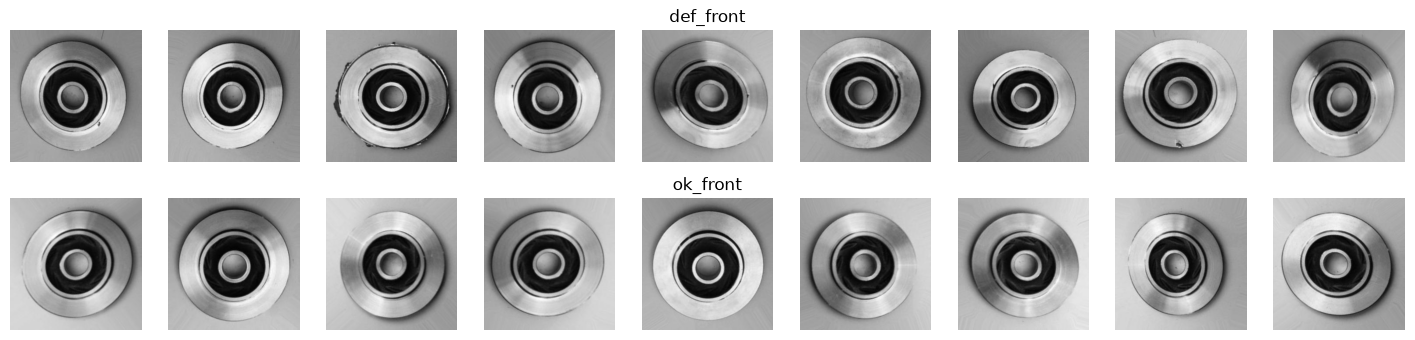

In [52]:
fig, axes = plt.subplots(2, 9, figsize=(18, 4))
for i, cls in enumerate(samples_by_class):
    for j, im_path in enumerate(samples_by_class[cls]):
        img = Image.open(im_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 4:
            axes[i, j].set_title(cls)

In [53]:
fig.savefig("../reports/figures/sample_grid.png", bbox_inches="tight")

## 4. Duplicate / near-duplicate detection

In [54]:
print(f"phash: {img_df['phash'].nunique()} , total images: {len(img_df)}")
img_df.head()

phash: 6856 , total images: 7348


,filepath,split,class,width,height,mode,mean_px,std_px,phash
0,../data/raw/train/def_front/cast_def_0_9253.jpeg,train,def_front,300,300,RGB,152.461133,62.767939,f09287691c67339e
1,../data/raw/train/def_front/cast_def_0_9071.jpeg,train,def_front,300,300,RGB,141.844200,54.154159,af87929869392667
2,../data/raw/train/def_front/cast_def_0_838.jpeg,train,def_front,300,300,RGB,138.020244,57.387111,e56b9a3639982633
3,../data/raw/train/def_front/cast_def_0_6849.jpeg,train,def_front,300,300,RGB,154.651689,63.690401,bda4d2da6c192636
4,../data/raw/train/def_front/cast_def_0_5259.jpeg,train,def_front,300,300,RGB,138.613878,60.255102,fa68871f3cd83261


In [55]:
img_df.columns

Index(['filepath', 'split', 'class', 'width', 'height', 'mode', 'mean_px',
       'std_px', 'phash'],
      dtype='str')

In [56]:
#Isolate and inspect the actual duplicate groups
dupe_counts = img_df["phash"].value_counts()
dupe_hashes = dupe_counts[dupe_counts > 1]
print(dupe_hashes)

phash
f46a8b343cb232cb    13
f1938e1c796626c9     7
f04b8b353c72329b     6
a51ede606927278e     6
f594ca493d27629c     5
                    ..
a03ddfe29c856364     2
f094cb4bbc323339     2
b5c2c23d6d32278b     2
b4c1cb9e9c787261     2
a4c6db096c3373d8     2
Name: count, Length: 402, dtype: int64


In [57]:
# Check the top hash for train/test leakage
top_hash = dupe_hashes.index[0]
img_df[img_df["phash"] == top_hash][["filepath", "split", "class"]]

,filepath,split,class
4446,../data/raw/train/ok_front/cast_ok_0_1785.jpeg,train,ok_front
4803,../data/raw/train/ok_front/cast_ok_0_935.jpeg,train,ok_front
5061,../data/raw/train/ok_front/cast_ok_0_474.jpeg,train,ok_front
5902,../data/raw/train/ok_front/cast_ok_0_1723.jpeg,train,ok_front
5923,../data/raw/train/ok_front/cast_ok_0_8465.jpeg,train,ok_front
6283,../data/raw/train/ok_front/cast_ok_0_6769.jpeg,train,ok_front
6375,../data/raw/train/ok_front/cast_ok_0_1.jpeg,train,ok_front
6484,../data/raw/train/ok_front/cast_ok_0_5837.jpeg,train,ok_front
6493,../data/raw/train/ok_front/cast_ok_0_510.jpeg,train,ok_front
6600,../data/raw/train/ok_front/cast_ok_0_3544.jpeg,train,ok_front


In [89]:
sample_pair = img_df[img_df["phash"] == top_hash]
for i in range(len(sample_pair)-1):
    gray_img_1 = Image.open(sample_pair.iloc[i]["filepath"]).convert("L")
    gray_img_2 = Image.open(sample_pair.iloc[i + 1]["filepath"]).convert("L")

    arr1 = np.asarray(gray_img_1, dtype=np.float64)
    arr2 = np.asarray(gray_img_2, dtype=np.float64)
    diff = np.abs(arr1 - arr2)
    print(diff.mean(), diff.std(), diff.max())


20.95577777777778 24.532625441679258 233.0
21.680522222222223 27.74279947731294 234.0
11.931688888888889 18.261254071360092 189.0
10.816788888888889 16.157815457401167 175.0
21.71773333333333 29.59752191158352 235.0
22.835444444444445 32.26199052414849 233.0
23.14211111111111 32.44228214997776 237.0
22.911366666666666 33.24839444275635 238.0
22.194488888888888 36.37284665890338 234.0
5.115911111111111 9.125811267004575 103.0
21.912366666666667 36.11188936807686 237.0
22.90728888888889 32.09441218559339 236.0


In [92]:
sample_pair = img_df[img_df["filepath"].str.contains("/ok_front/cast_ok_0_935.jpeg")] #.sort_values("filepath")

for i in range(len(sample_pair)-1):
    gray_img_1 = Image.open(sample_pair.iloc[i]["filepath"]).convert("L")
    gray_img_2 = Image.open(sample_pair.iloc[i + 1]["filepath"]).convert("L")

    arr1 = np.asarray(gray_img_1, dtype=np.float64)
    arr2 = np.asarray(gray_img_2, dtype=np.float64)
    diff = np.abs(arr1 - arr2)
    print(diff.mean(), diff.std(), diff.max())


0.0 0.0 0.0


### Findings
- phash equality gives false positives on this dataset (13 visibly different images shared one hash), and at least one pixel-identical image (cast_ok_0_935.jpeg)